# Detección de objetos con YOLOv11

YOLO (You Only Look Once) es una familia de modelos de detección de objetos en tiempo real. En esta sección, se muestra cómo utilizar un modelo YOLOv11 para detectar objetos en imágenes.

In [30]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

image_path = "./image.png"

In [31]:
# Load a pretrained YOLO11 model
model_s = YOLO("yolo11s.pt")
model_m = YOLO("yolo11m.pt")
model_l = YOLO("yolo11l.pt")

📝 YOLO fue entrenado en el conjunto de datos COCO, que contiene 80 clases de objetos comunes. Se puede utilizar directamente el modelo YOLOv11 preentrenado para realizar detección de objetos en imágenes.

In [32]:
results = model_s.predict(source=image_path, device="cpu", conf=0.25, imgsz=640, verbose=True)

r = results[0]

annotated = r.plot()[:, :, ::-1]


image 1/1 /home/comejia/projects/ceia/ceia-computer-vision-ii/2026/Clase_4/image.png: 448x640 6 persons, 3 cars, 2 backpacks, 3 handbags, 3 bottles, 1 chair, 1 dining table, 91.7ms
Speed: 3.2ms preprocess, 91.7ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


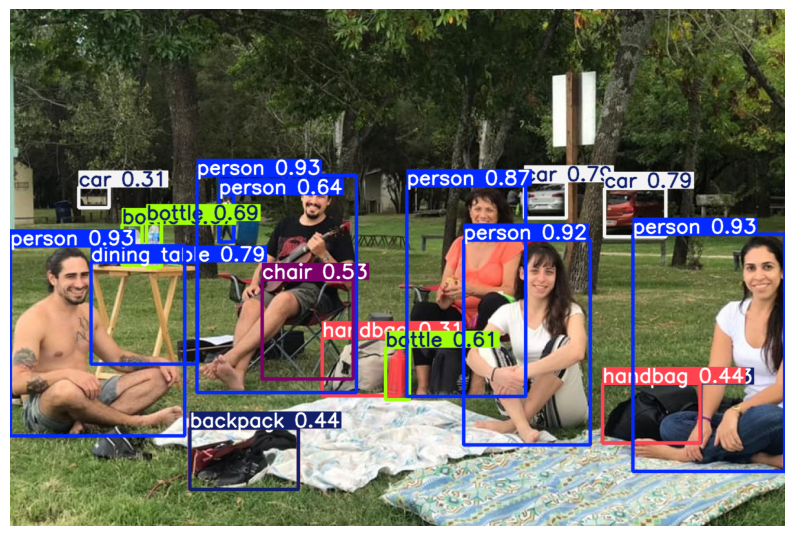

In [33]:
def plot_detections(annotated):
    plt.figure(figsize=(10, 7))
    plt.imshow(annotated)
    plt.axis("off")
    plt.show()


plot_detections(annotated)

In [34]:
for b in r.boxes:
    cls = int(b.cls[0])
    conf = b.conf[0]
    x1, y1, x2, y2 = b.xyxy[0]
    print(
        f"Class: {model_s.names[cls]}, Confidence: {conf:.3f}, Bounding Box: [{x1:.2f}, {y1:.2f}, {x2:.2f}, {y2:.2f}]"
    )

Class: person, Confidence: 0.934, Bounding Box: [0.03, 366.53, 270.86, 660.72]
Class: person, Confidence: 0.931, Bounding Box: [289.19, 257.49, 536.46, 593.85]
Class: person, Confidence: 0.929, Bounding Box: [964.95, 348.33, 1199.50, 715.90]
Class: person, Confidence: 0.917, Bounding Box: [702.47, 357.26, 898.62, 674.89]
Class: person, Confidence: 0.871, Bounding Box: [614.85, 273.42, 798.31, 599.40]
Class: dining table, Confidence: 0.794, Bounding Box: [125.54, 391.54, 290.82, 549.83]
Class: car, Confidence: 0.794, Bounding Box: [920.87, 277.76, 1015.95, 352.63]
Class: car, Confidence: 0.785, Bounding Box: [796.93, 267.33, 861.01, 323.62]
Class: bottle, Confidence: 0.691, Bounding Box: [211.62, 327.06, 234.05, 399.16]
Class: bottle, Confidence: 0.669, Bounding Box: [173.16, 333.97, 204.27, 396.48]
Class: person, Confidence: 0.639, Bounding Box: [323.59, 287.08, 346.82, 360.18]
Class: bottle, Confidence: 0.615, Bounding Box: [581.75, 523.24, 618.17, 604.51]
Class: chair, Confidence: 0.

---

Pruebas con otros modelos mas grandes:


image 1/1 /home/comejia/projects/ceia/ceia-computer-vision-ii/2026/Clase_4/image.png: 448x640 6 persons, 1 car, 2 bottles, 1 chair, 1 dining table, 260.7ms
Speed: 3.5ms preprocess, 260.7ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


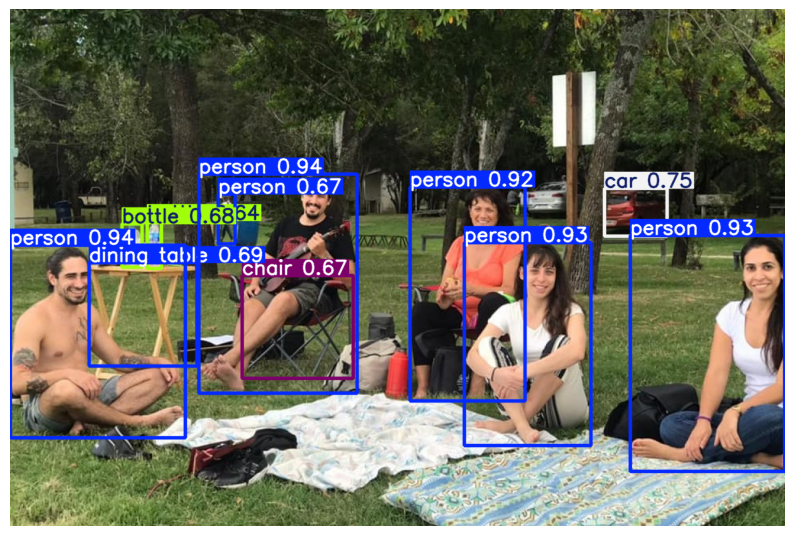

In [35]:
results = model_l.predict(source=image_path, device="cpu", conf=0.6, imgsz=640, verbose=True)

r = results[0]

annotated = r.plot()[:, :, ::-1]

plot_detections(annotated)